In [1]:
! pip install bnlp_toolkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 910.8 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.4 MB/s eta 0:00:00


In [2]:
!rm -rf /kaggle/working/*

In [3]:
# ---------------------------------------------------------
# Standard Library
# ---------------------------------------------------------
import re
import time
import random
from collections import Counter
from itertools import cycle

# ---------------------------------------------------------
# Data Manipulation, Visualization & Utilities
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import seaborn as sns
from PIL import Image
from wordcloud import WordCloud
from tabulate import tabulate
from tqdm.auto import tqdm
from bnlp import CleanText, BengaliCorpus, NLTKTokenizer
import matplotlib.font_manager as fm

# ---------------------------------------------------------
# PyTorch Deep Learning
# ---------------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

# ---------------------------------------------------------
# Scikit-Learn Machine Learning & Metrics
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    classification_report,
    multilabel_confusion_matrix,
    hamming_loss
)

# ---------------------------------------------------------
# Jupyter/IPython Magics
# ---------------------------------------------------------
%matplotlib inline

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
df=pd.read_csv("/kaggle/input/datasets/mdabdullahalkafi/boishommo-multi-label-hate-speech-dataset/Bengali Heatspeech dataset.csv")
my_image=np.array(Image.open("/kaggle/input/datasets/programminghero009/bangla-font/twitter.png"))
my_font="/kaggle/input/datasets/programminghero009/bangla-font/kalpurush.ttf"

In [7]:
df.head()

,Text,Race,Behaviour,Physical,Class,Religion,Disability,Ethnicity,Gender,Sexual Orientation,Political
0,বৌদির দুধ দেকে তো আমার ই চোখ ঠিক ছিলো না - পোল...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,এই সরকার কে যারা নির্লজ্জের মত সাপোর্ট দিয়েছে ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,পিলখানা হত্যাকান্ড বাংলাদেশের প্রতিরক্ষা ব্যবস...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,ভারতের অর্থনীতি নিয়ে আপনাদের ভাবতে হবে না। ভা...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,খানকির পুলা মালায়নদের মেরে সাফা করে ফেল,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [8]:
df.shape

(5698, 11)

In [9]:
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

In [10]:
df.columns

Index(['Text', 'Race', 'Behaviour', 'Physical', 'Class', 'Religion',
       'Disability', 'Ethnicity', 'Gender', 'Sexual Orientation', 'Political'],
      dtype='object')

In [11]:
# List of your label columns
label_cols = ['Race', 'Behaviour', 'Physical', 'Class', 'Religion', 
              'Disability', 'Ethnicity', 'Gender', 'Sexual Orientation', 'Political']

# Loop through each column and fill NaN with its mode
for col in label_cols:
    # Check if the column is not completely empty to avoid errors
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

Text                  0
Race                  0
Behaviour             0
Physical              0
Class                 0
Religion              0
Disability            0
Ethnicity             0
Gender                0
Sexual Orientation    0
Political             0
dtype: int64

In [13]:
null_label_samples = df[df[label_cols].isnull().any(axis=1)]

display(null_label_samples)

,Text,Race,Behaviour,Physical,Class,Religion,Disability,Ethnicity,Gender,Sexual Orientation,Political


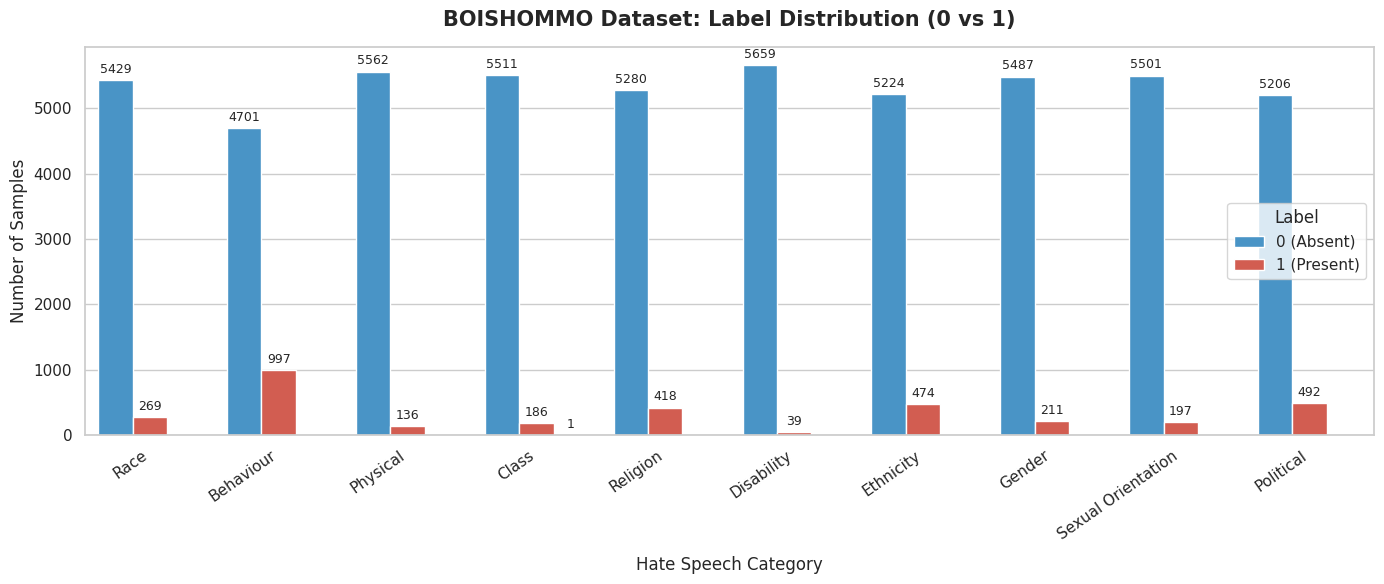

In [14]:
# 1. Define target label columns
label_cols = [
    'Race', 'Behaviour', 'Physical', 'Class', 'Religion', 
    'Disability', 'Ethnicity', 'Gender', 'Sexual Orientation', 'Political'
]

# 2. Reshape dataframe for multi-label countplot
df_melted = df.melt(value_vars=label_cols, var_name='Category', value_name='Label')

# 3. Plotting setup
plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')

ax = sns.countplot(
    data=df_melted, 
    x='Category', 
    hue='Label', 
    palette=['#3498db', '#e74c3c']  # Blue for 0, Red for 1
)

# 4. Styling the plot
plt.title('BOISHOMMO Dataset: Label Distribution (0 vs 1)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Hate Speech Category', fontsize=12, labelpad=10)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.legend(title='Label',labels=['0 (Absent)', '1 (Present)'],frameon=True)

# Add exact count values on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [15]:
corpus = BengaliCorpus()
print(corpus.stopwords)
print(corpus.punctuations)
print(corpus.letters)
print(corpus.digits)
print(corpus.vowels)

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

In [16]:
tqdm.pandas()

cleaner = CleanText(
    fix_unicode=True,
    unicode_norm=True,
    unicode_norm_form="NFKC",
    remove_url=True,
    remove_email=True,
    remove_emoji=True,
    remove_number=True,
    remove_digits=True,
    remove_punct=True,
    replace_with_url="",
    replace_with_email="",
    replace_with_number="",
    replace_with_digit="",
    replace_with_punct=""
)

df["Text"] = (df["Text"].astype(str).progress_apply(cleaner).str.replace(r"\s+", " ", regex=True).str.strip())

stop_words = corpus.stopwords

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df["Text"] = df["Text"].progress_apply(remove_stopwords)

  0%|          | 0/5698 [00:00<?, ?it/s]

  0%|          | 0/5698 [00:00<?, ?it/s]

In [17]:
has_english = df["Text"].str.contains(r'[a-zA-Z]', na=False).any()
print("Contains English letters:", has_english)

Contains English letters: True


In [18]:
# Filter the dataset to only show rows with English text
english_rows = df[df["Text"].str.contains(r'[a-zA-Z]', na=False)]

# Display the text of those rows
print(english_rows["Text"].head(10))

701     সিটি কর্পোরেশনের মানুষরূপী কুকুরগyলো নিধন দরকা...
1240                              Bong বাইনচোদ দের চালাবে
3300       নিজেরই যোগ্যতা মিস বাংলাদেশ আইসে অন্যদের judge
4984    হিন্দু NRC সমর্থনে ঝাপিয়ে পড়ুন ধংশো কারি মুস...
5059       ছাত্র লীগের এসব যুক্তি হীন কথা বন্ধ হবেRUBBISH
5609    বাঙালি থাকলে ন্যাংটা খোলা আকাশের নিচে tot tot ...
Name: Text, dtype: object


In [19]:
tqdm.pandas()

def remove_all_english(text):
    text = str(text)
    text = re.sub(r'[a-zA-Z]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Text'] = df['Text'].progress_apply(remove_all_english)

  0%|          | 0/5698 [00:00<?, ?it/s]

In [20]:
has_english = df["Text"].str.contains(r'[a-zA-Z]', na=False).any()
print("Contains English letters:", has_english)

Contains English letters: False


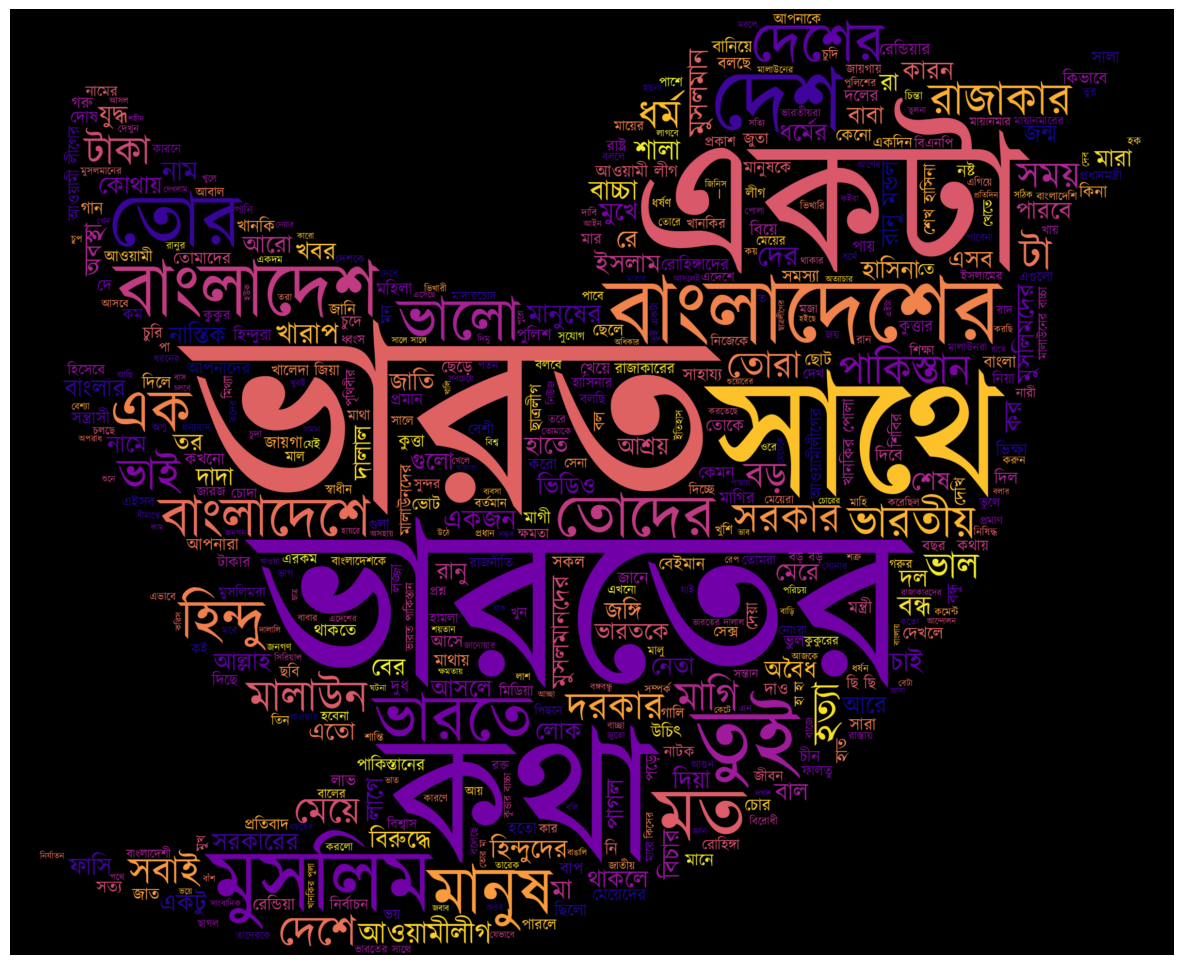

In [21]:
# Join all text from the entire dataset into a single string
wordcloud_text = " ".join(df["Text"].astype(str))

# Set the Regex for Bengali characters
regex = r"[\u0980-\u09FF]+"

# Set stopwords
stopwords = set(corpus.stopwords)

# Generate the WordCloud
wc = WordCloud(
    width=1200,
    height=1200,
    background_color="black",
    colormap="plasma",
    mask=my_image,        # Make sure your mask image variable is defined
    stopwords=stopwords,
    font_path=my_font,    # Make sure this points to your Bengali .ttf font!
    regexp=regex,
    max_words=500,
    random_state=42
).generate(wordcloud_text)

# Plot the WordCloud
plt.figure(figsize=(12, 12))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()

# Save and Show
plt.savefig("dataset_wordcloud.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()

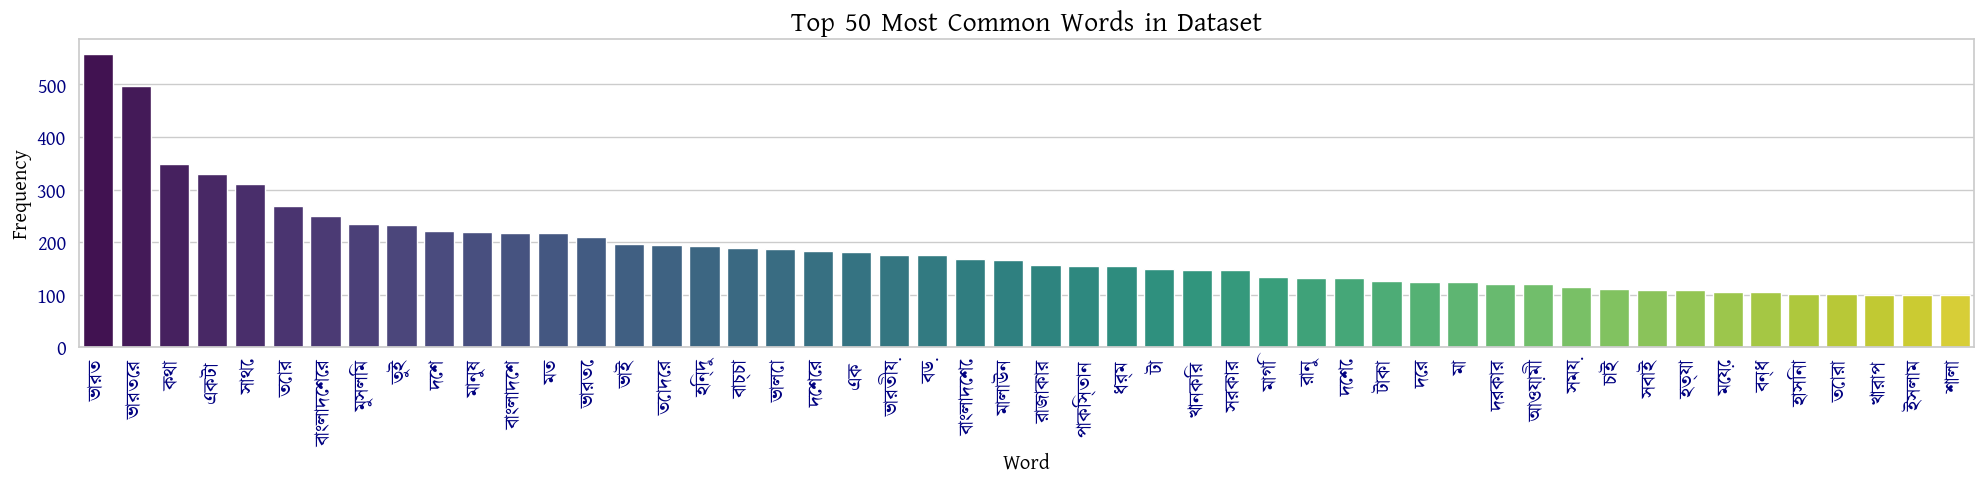

In [22]:
# 1. Get the top 50 words for the entire text column
top_words = df['Text'].str.split(expand=True).stack().value_counts().head(50)

# 2. Set up the Bengali font
font_path = "/kaggle/input/datasets/programminghero009/bangla-font/kalpurush.ttf"
my_font = fm.FontProperties(fname=font_path)

# 3. Create the plot (widened slightly to fit 50 words)
plt.figure(figsize=(20, 5))
sns.barplot(x=top_words.index, y=top_words.values, palette="viridis")

# 4. Set titles and labels
plt.title('Top 50 Most Common Words in Dataset', fontproperties=my_font, fontsize=20, color="black")
plt.xlabel('Word', fontproperties=my_font, fontsize=15, color="black")
plt.ylabel('Frequency', fontproperties=my_font, fontsize=15, color="black")

# 5. Apply font to ticks and rotate X-axis labels
plt.xticks(rotation=90, fontproperties=my_font, fontsize=15, color="navy")
plt.yticks(fontproperties=my_font, fontsize=15, color="navy")

plt.tight_layout()

# 6. Save and show
plt.savefig("top_50_common_words.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

95th Percentile Word Count: 28.0
Max Word Count: 76


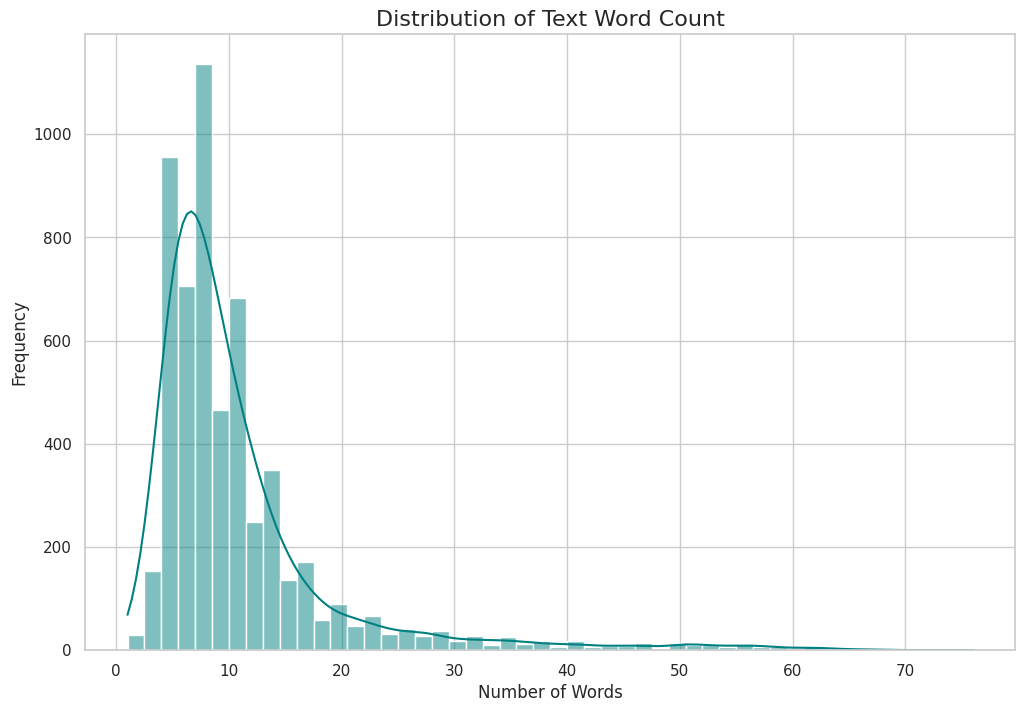

In [23]:
# Calculate word count and character count
df['word_count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 8))
sns.histplot(df['word_count'], bins=50, kde=True, color="teal")
plt.title("Distribution of Text Word Count", fontsize=16)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Print key statistics to decide max_seq_length
print("95th Percentile Word Count:", df['word_count'].quantile(0.95))
print("Max Word Count:", df['word_count'].max())

plt.savefig("word_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

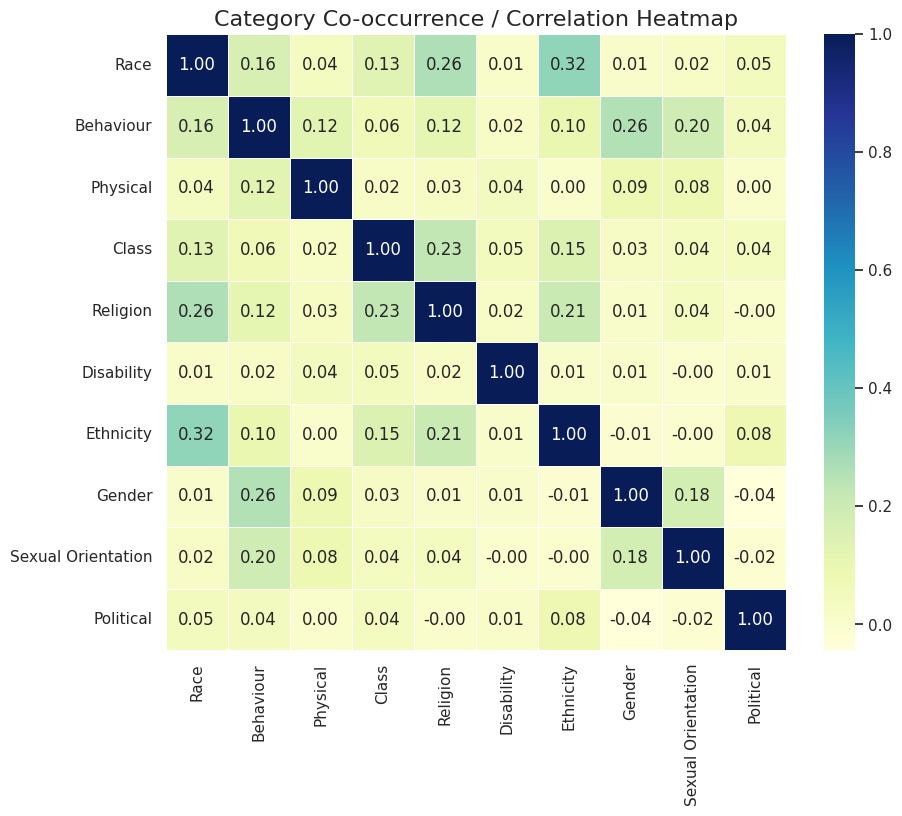

In [24]:
plt.figure(figsize=(10, 8))
label_cols = ['Race', 'Behaviour', 'Physical', 'Class', 'Religion', 'Disability', 'Ethnicity', 'Gender', 'Sexual Orientation', 'Political']
correlation_matrix = df[label_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Category Co-occurrence / Correlation Heatmap", fontsize=16)

plt.savefig("label_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

--- Sentence Length Statistics ---
Average (Mean) Length:  10.85 words
Median Length:          8 words
Maximum Length:         76 words
--------------------------------
90% of texts are under: 19 words
95% of texts are under: 28 words
99% of texts are under: 52 words


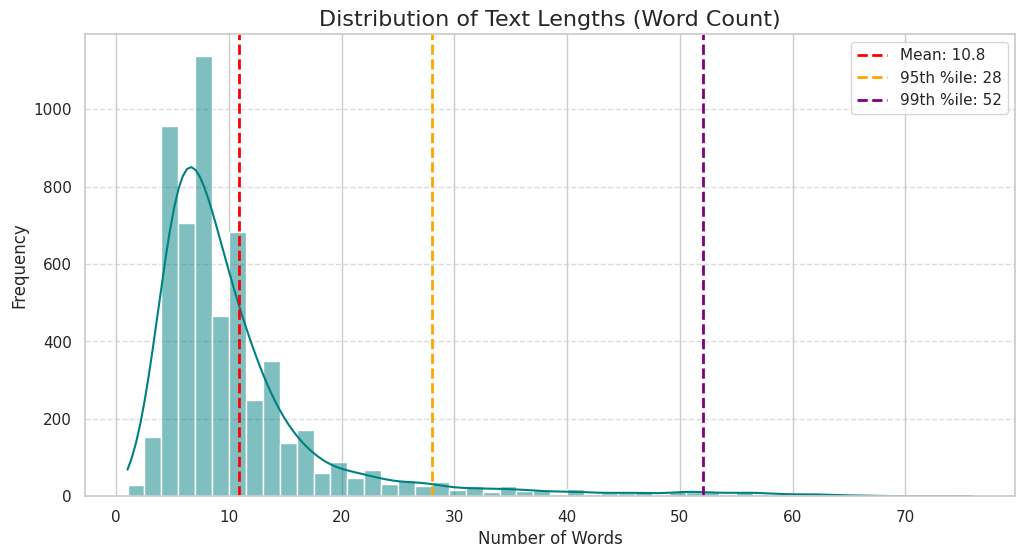

In [25]:
# 1. Calculate word count for each row in the 'Text' column
df['word_count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

# 2. Calculate key statistical metrics
mean_len = df['word_count'].mean()
median_len = df['word_count'].median()
max_len = df['word_count'].max()

# Calculate percentiles to see where the majority of your data falls
p90 = df['word_count'].quantile(0.90)
p95 = df['word_count'].quantile(0.95)
p99 = df['word_count'].quantile(0.99)

print("--- Sentence Length Statistics ---")
print(f"Average (Mean) Length:  {mean_len:.2f} words")
print(f"Median Length:          {median_len:.0f} words")
print(f"Maximum Length:         {max_len} words")
print("-" * 32)
print(f"90% of texts are under: {p90:.0f} words")
print(f"95% of texts are under: {p95:.0f} words")
print(f"99% of texts are under: {p99:.0f} words")

# 3. Plot the distribution with guiding lines
plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')

# Add vertical lines to visualize the mean and percentiles
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f}')
plt.axvline(p95, color='orange', linestyle='dashed', linewidth=2, label=f'95th %ile: {p95:.0f}')
plt.axvline(p99, color='purple', linestyle='dashed', linewidth=2, label=f'99th %ile: {p99:.0f}')

plt.title('Distribution of Text Lengths (Word Count)', fontsize=16)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("sentence_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
df.head()

,Text,Race,Behaviour,Physical,Class,Religion,Disability,Ethnicity,Gender,Sexual Orientation,Political,word_count
0,বৌদির দুধ দেকে চোখ ছিলো পোলাপান চোখ কিভাবে,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8
1,সরকার নির্লজ্জের মত সাপোর্ট বছরের বছর আরো রাস্...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10
2,পিলখানা হত্যাকান্ড বাংলাদেশের প্রতিরক্ষা ব্যবস...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,11
3,ভারতের অর্থনীতি আপনাদের ভাবতে ভারতের অর্থনীতি ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13
4,খানকির পুলা মালায়নদের মেরে সাফা ফেল,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,6


In [27]:
# 1. First split: 80% Train, 20% Temp (Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)

# 2. Second split: Split Temp 50/50 for 10% Val and 10% Test
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

In [28]:
class CustomVocab:
    def __init__(self, texts, min_freq=2):
        # 0 is reserved for Padding, 1 is reserved for Unknown words
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.build_vocab(texts, min_freq)
        
    def build_vocab(self, texts, min_freq):
        word_counts = Counter()
        for text in texts:
            words = str(text).split()
            word_counts.update(words)
            
        # Add words to vocab if they appear enough times
        idx = 2
        for word, count in word_counts.items():
            if count >= min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
                
    def text_to_sequence(self, text, max_len):
        words = str(text).split()
        # Convert words to IDs; use <UNK> ID (1) if word is not in vocab
        sequence = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in words]
        
        # Truncate if the text is too long
        if len(sequence) > max_len:
            sequence = sequence[:max_len]
        # Pad with 0s if the text is too short
        else:
            sequence = sequence + [self.word2idx['<PAD>']] * (max_len - len(sequence))
            
        return sequence

# Initialize and build vocab ONLY on the training data
# min_freq=2 removes typos or super rare words to keep the model fast
vocab = CustomVocab(train_df['Text'].values, min_freq=2)
print(f"Total Unique Words in Vocab: {len(vocab.word2idx)}")

Total Unique Words in Vocab: 5339


In [29]:
class ScratchBengaliDataset(Dataset):
    def __init__(self, dataframe, vocab, max_len):
        self.dataframe = dataframe.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        
        # The 10 target columns based on your image
        self.label_cols = [
            'Race', 'Behaviour', 'Physical', 'Class', 'Religion', 
            'Disability', 'Ethnicity', 'Gender', 'Sexual Orientation', 'Political'
        ]
        
        self.texts = self.dataframe['Text'].astype(str).values
        self.labels = self.dataframe[self.label_cols].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        labels = self.labels[index]

        # Convert text to a padded/truncated sequence of integer IDs
        sequence = self.vocab.text_to_sequence(text, self.max_len)

        return {
            'text': text,
            # Features must be LongTensors for PyTorch Embedding layers
            'input_ids': torch.tensor(sequence, dtype=torch.long), 
            # Multi-label targets must be FloatTensors for BCEWithLogitsLoss
            'labels': torch.tensor(labels, dtype=torch.float)      
        }

In [30]:
MAX_LEN = 55  # Adjust based on your EDA word_count results
BATCH_SIZE = 32 # Standard batch size for custom models

# Create Datasets
train_dataset = ScratchBengaliDataset(train_df, vocab, MAX_LEN)
val_dataset = ScratchBengaliDataset(val_df, vocab, MAX_LEN)
test_dataset = ScratchBengaliDataset(test_df, vocab, MAX_LEN)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Quick test to see the batch shape
sample_batch = next(iter(train_loader))
print("Input IDs shape:", sample_batch['input_ids'].shape) 
print("Labels shape:", sample_batch['labels'].shape)       

Input IDs shape: torch.Size([32, 55])
Labels shape: torch.Size([32, 10])


In [31]:
# Size of the word vectors (128 or 256 is standard)
EMBEDDING_DIM = 128              

# Number of features in the hidden state (128 or 256 is standard)
HIDDEN_DIM = 256                 

# Your 10 target categories
OUTPUT_DIM = 10                  

In [32]:
class BengaliMultiLabelBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3):
        super(BengaliMultiLabelBiLSTM, self).__init__()
        
        # 1. Embedding Layer: Converts your integer IDs into dense math vectors
        # We pass padding_idx=0 so the model ignores our <PAD> tokens completely
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. BiLSTM Layer: Reads text left-to-right AND right-to-left
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers, 
            bidirectional=True, 
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        
        # 3. Dropout: Randomly turns off neurons to prevent overfitting
        self.dropout = nn.Dropout(dropout)
        
        # 4. Fully Connected Layer: Maps the LSTM output to your 10 categories
        # We multiply hidden_dim by 2 because the LSTM is bidirectional
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        # text shape: [batch_size, max_len] (e.g., [32, 55])
        
        # 1. Pass through embedding
        embedded = self.embedding(text) 
        
        # 2. Pass through LSTM
        # We only care about the 'hidden' states for classification
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # 3. Concatenate the final forward and backward hidden states
        hidden_concat = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        
        # 4. Apply dropout
        dropped = self.dropout(hidden_concat)
        
        # 5. Final predictions (Logits)
        logits = self.fc(dropped)
        
        return logits

In [33]:
# --- Model Hyperparameters ---
# The size of our vocabulary (plus PAD and UNK)
INPUT_DIM = len(vocab.word2idx)  


# Instantiate the model
model = BengaliMultiLabelBiLSTM(
    vocab_size=INPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=2,       # 2 layers is a good sweet spot
    dropout=0.3       # 30% dropout to prevent memorizing the training data
)

# Move the model to the GPU if you are using Kaggle's T4 or P100 accelerators

model = model.to(device)


# Print the detailed architecture summary
summary(
    model, 
    input_size=(BATCH_SIZE, MAX_LEN), # Uses (32, 55) based on our DataLoader setup
    dtypes=[torch.long],              # Required because Embedding layers expect integer IDs
    col_names=["input_size", "output_size", "num_params", "trainable"],
    device=device                     # Ensures the dummy input is on the same device as the model
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BengaliMultiLabelBiLSTM                  [32, 55]                  [32, 10]                  --                        True
├─Embedding: 1-1                         [32, 55]                  [32, 55, 128]             683,392                   True
├─LSTM: 1-2                              [32, 55, 128]             [32, 55, 512]             2,367,488                 True
├─Dropout: 1-3                           [32, 512]                 [32, 512]                 --                        --
├─Linear: 1-4                            [32, 512]                 [32, 10]                  5,130                     True
Total params: 3,056,010
Trainable params: 3,056,010
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 4.19
Input size (MB): 0.01
Forward/backward pass size (MB): 9.01
Params size (MB): 12.22
Estimated Total Size (MB): 21.25

In [34]:
def train_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device,
    threshold=0.5
):
    model.train()

    total_loss = 0.0
    total_acc = 0.0

    pbar = tqdm(
        dataloader,
        desc="Train",
        leave=False
    )

    for batch in pbar:

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device).float()

        optimizer.zero_grad()

        logits = model(input_ids)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        # Multi-label prediction
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        # Element-wise accuracy
        acc = (
            (preds == labels)
            .float()
            .mean()
            .item()
        )

        total_loss += loss.item()
        total_acc += acc

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{acc * 100:.2f}%"
        })

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_acc / len(dataloader)

    return avg_loss, avg_acc


def validate_epoch(
    model,
    dataloader,
    criterion,
    device,
    threshold=0.5
):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0

    all_preds = []
    all_labels = []

    pbar = tqdm(
        dataloader,
        desc="Valid",
        leave=False
    )

    with torch.no_grad():

        for batch in pbar:

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()

            logits = model(input_ids)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()

            acc = (
                (preds == labels)
                .float()
                .mean()
                .item()
            )

            total_acc += acc

            all_preds.append(
                preds.cpu().numpy()
            )

            all_labels.append(
                labels.cpu().numpy()
            )

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_acc / len(dataloader)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    micro_f1 = f1_score(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    micro_precision = precision_score(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    micro_recall = recall_score(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    return (
        avg_loss,
        avg_acc,
        micro_f1,
        micro_precision,
        micro_recall
    )

In [35]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs,
    device,
    patience=12,
    checkpoint_path="best_bilstm_model.pth"
):
    """
    Train BiLSTM model with persistent per-epoch vertical metrics.

    Each completed epoch is displayed as its own:
        Metric | Value

    Previous epochs are NOT cleared.
    """

    history = []

    # Best validation loss
    best_val_loss = float("inf")

    # Early stopping counter
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):

        # Start epoch timer
        start_time = time.time()

        # Current learning rate
        current_lr = optimizer.param_groups[0]["lr"]

        # Train
        train_loss, train_acc = train_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        # Validate
        (
            val_loss,
            val_acc,
            micro_f1,
            micro_precision,
            micro_recall
        ) = validate_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        # Scheduler
        scheduler.step(val_loss)

        # Epoch time
        epoch_time = time.time() - start_time

        # Check best model
        is_best = val_loss < best_val_loss

        if is_best:

            best_val_loss = val_loss
            epochs_no_improve = 0

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

            best_model = "YES"

        else:

            epochs_no_improve += 1
            best_model = "NO"

        # Store complete epoch history
        epoch_result = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "learning_rate": current_lr,
            "epoch_time": epoch_time,
            "patience": epochs_no_improve,
            "micro_f1": micro_f1,
            "precision": micro_precision,
            "recall": micro_recall,
            "best_model": best_model
        }

        history.append(epoch_result)

        # Current epoch vertical table
        table_data = [
            ["Epoch", str(epoch)],
            ["Train Loss", f"{train_loss:.4f}"],
            ["Train Acc", f"{train_acc * 100:.2f}%"],
            ["Val Loss", f"{val_loss:.4f}"],
            ["Val Acc", f"{val_acc * 100:.2f}%"],
            ["Learning Rate", f"{current_lr:.2e}"],
            ["Epoch Time", f"{epoch_time:.2f}s"],
            ["Patience", str(epochs_no_improve)],
            ["Micro F1", f"{micro_f1:.4f}"],
            ["Precision", f"{micro_precision:.4f}"],
            ["Recall", f"{micro_recall:.4f}"],
            ["Best Model", best_model]
        ]

        # Display epoch heading
        print(f"\nEpoch {epoch}/{epochs}")

        # Display current epoch metrics
        print(
            tabulate(
                table_data,
                headers=["Metric", "Value"],
                tablefmt="fancy_grid"
            )
        )

        # Status
        if best_model == "YES":
            print("New best model saved.")

        else:
            print(
                f"No improvement. "
                f"Early stopping counter: "
                f"{epochs_no_improve}/{patience}"
            )

        # Early stopping
        if epochs_no_improve >= patience:

            print(
                f"\nEarly stopping triggered. "
                f"No validation-loss improvement for "
                f"{patience} consecutive epochs."
            )

            break

    # Load best model
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    print("\nBest model weights loaded successfully.")

    return history

In [36]:
# --- 0. PREPARE THE WEIGHTS ---
# Calculate pos_weight for each column: (Total Zeros / Total Ones)
pos_weights = []
for col in label_cols:
    num_ones = (df[col] == 1.0).sum()
    num_zeros = len(df) - num_ones
    weight = num_zeros / num_ones
    pos_weights.append(weight)

# Move the weights to the correct device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)

print("--- Calculated Positive Weights ---")
for col, w in zip(label_cols, pos_weights):
    print(f"{col:>18}: {w:.2f}")
print("-" * 33)

# ---------------------------------------------------------
# 1. Loss Function Selection
# ---------------------------------------------------------
# We inject the pos_weight tensor directly into the criterion.
# This mathematically forces the model to pay heavy attention to the rare '1's.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# ---------------------------------------------------------
# 2. Optimizer Initialization
# ---------------------------------------------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

# ---------------------------------------------------------
# 3. Learning Rate Scheduler
# ---------------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# ---------------------------------------------------------
# 4. Training Hyperparameters
# ---------------------------------------------------------
EPOCHS = 100       
PATIENCE = 20 

# ---------------------------------------------------------
# 5. Execute Training Loop
# ---------------------------------------------------------
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    device=device,
    patience=PATIENCE,
    checkpoint_path="best_bilstm_model.pth"
)

--- Calculated Positive Weights ---
              Race: 20.18
         Behaviour: 4.72
          Physical: 40.90
             Class: 29.63
          Religion: 12.63
        Disability: 145.10
         Ethnicity: 11.02
            Gender: 26.00
Sexual Orientation: 27.92
         Political: 10.58
---------------------------------


Train:   0%|          | 0/143 [00:00<?, ?it/s]

Valid:   0%|          | 0/18 [00:00<?, ?it/s]


Epoch 1/100
╒═══════════════╤══════════╕
│ Metric        │ Value    │
╞═══════════════╪══════════╡
│ Epoch         │ 1        │
├───────────────┼──────────┤
│ Train Loss    │ 1.3035   │
├───────────────┼──────────┤
│ Train Acc     │ 54.28%   │
├───────────────┼──────────┤
│ Val Loss      │ 1.2989   │
├───────────────┼──────────┤
│ Val Acc       │ 64.11%   │
├───────────────┼──────────┤
│ Learning Rate │ 1.00e-04 │
├───────────────┼──────────┤
│ Epoch Time    │ 2.41s    │
├───────────────┼──────────┤
│ Patience      │ 0        │
├───────────────┼──────────┤
│ Micro F1      │ 0.1009   │
├───────────────┼──────────┤
│ Precision     │ 0.0604   │
├───────────────┼──────────┤
│ Recall        │ 0.3059   │
├───────────────┼──────────┤
│ Best Model    │ YES      │
╘═══════════════╧══════════╛
New best model saved.


Train:   0%|          | 0/143 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/18 [00:00<?, ?it/s]


Epoch 23/100
╒═══════════════╤══════════╕
│ Metric        │ Value    │
╞═══════════════╪══════════╡
│ Epoch         │ 23       │
├───────────────┼──────────┤
│ Train Loss    │ 0.7879   │
├───────────────┼──────────┤
│ Train Acc     │ 79.98%   │
├───────────────┼──────────┤
│ Val Loss      │ 1.5028   │
├───────────────┼──────────┤
│ Val Acc       │ 78.40%   │
├───────────────┼──────────┤
│ Learning Rate │ 1.56e-06 │
├───────────────┼──────────┤
│ Epoch Time    │ 2.00s    │
├───────────────┼──────────┤
│ Patience      │ 19       │
├───────────────┼──────────┤
│ Micro F1      │ 0.2290   │
├───────────────┼──────────┤
│ Precision     │ 0.1498   │
├───────────────┼──────────┤
│ Recall        │ 0.4867   │
├───────────────┼──────────┤
│ Best Model    │ NO       │
╘═══════════════╧══════════╛
No improvement. Early stopping counter: 19/20


Train:   0%|          | 0/143 [00:00<?, ?it/s]

Valid:   0%|          | 0/18 [00:00<?, ?it/s]


Epoch 24/100
╒═══════════════╤══════════╕
│ Metric        │ Value    │
╞═══════════════╪══════════╡
│ Epoch         │ 24       │
├───────────────┼──────────┤
│ Train Loss    │ 0.7878   │
├───────────────┼──────────┤
│ Train Acc     │ 79.67%   │
├───────────────┼──────────┤
│ Val Loss      │ 1.5054   │
├───────────────┼──────────┤
│ Val Acc       │ 78.48%   │
├───────────────┼──────────┤
│ Learning Rate │ 1.56e-06 │
├───────────────┼──────────┤
│ Epoch Time    │ 1.99s    │
├───────────────┼──────────┤
│ Patience      │ 20       │
├───────────────┼──────────┤
│ Micro F1      │ 0.2267   │
├───────────────┼──────────┤
│ Precision     │ 0.1485   │
├───────────────┼──────────┤
│ Recall        │ 0.4787   │
├───────────────┼──────────┤
│ Best Model    │ NO       │
╘═══════════════╧══════════╛
No improvement. Early stopping counter: 20/20

Early stopping triggered. No validation-loss improvement for 20 consecutive epochs.

Best model weights loaded successfully.


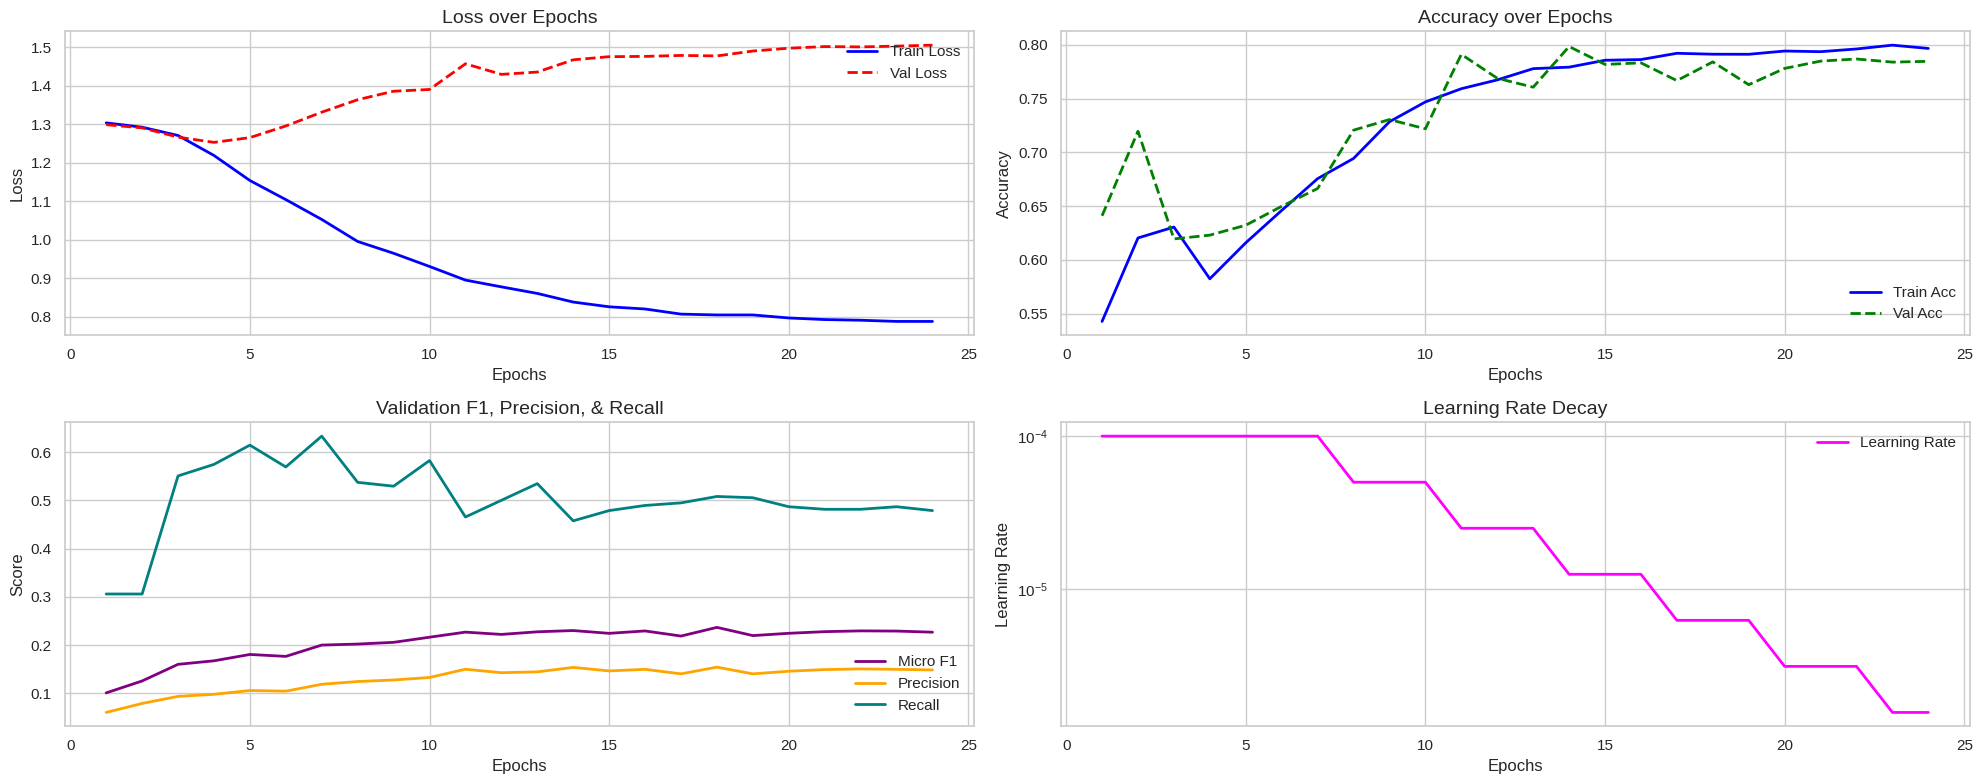

In [37]:
# Extract metrics from the history list
epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
train_acc = [h["train_acc"] for h in history]
val_acc = [h["val_acc"] for h in history]
micro_f1 = [h["micro_f1"] for h in history]
precision = [h["precision"] for h in history]
recall = [h["recall"] for h in history]
learning_rates = [h["learning_rate"] for h in history]

# Set up the matplotlib figure and axes (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(20, 8))
plt.style.use("seaborn-v0_8-darkgrid") # Gives the plots a nice aesthetic

# 1. Training and Validation Loss
axes[0, 0].plot(epochs, train_loss, label="Train Loss", color="blue", linewidth=2)
axes[0, 0].plot(epochs, val_loss, label="Val Loss", color="red", linewidth=2, linestyle="--")
axes[0, 0].set_title("Loss over Epochs", fontsize=14)
axes[0, 0].set_xlabel("Epochs")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(loc="upper right")

# 2. Training and Validation Accuracy
axes[0, 1].plot(epochs, train_acc, label="Train Acc", color="blue", linewidth=2)
axes[0, 1].plot(epochs, val_acc, label="Val Acc", color="green", linewidth=2, linestyle="--")
axes[0, 1].set_title("Accuracy over Epochs", fontsize=14)
axes[0, 1].set_xlabel("Epochs")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(loc="lower right")

# 3. Validation Metrics (F1, Precision, Recall)
axes[1, 0].plot(epochs, micro_f1, label="Micro F1", color="purple", linewidth=2)
axes[1, 0].plot(epochs, precision, label="Precision", color="orange", linewidth=2)
axes[1, 0].plot(epochs, recall, label="Recall", color="teal", linewidth=2)
axes[1, 0].set_title("Validation F1, Precision, & Recall", fontsize=14)
axes[1, 0].set_xlabel("Epochs")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend(loc="lower right")

# 4. Learning Rate Decay
axes[1, 1].plot(epochs, learning_rates, label="Learning Rate", color="magenta", linewidth=2)
axes[1, 1].set_title("Learning Rate Decay", fontsize=14)
axes[1, 1].set_xlabel("Epochs")
axes[1, 1].set_ylabel("Learning Rate")
axes[1, 1].set_yscale("log") # Log scale is usually best for viewing LR decay
axes[1, 1].legend(loc="upper right")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [38]:
# Extract the labels dynamically from the dataset inside the dataloader
my_class_names = test_loader.dataset.label_cols

# Print to verify
print("Dynamically extracted labels:", my_class_names)

Dynamically extracted labels: ['Race', 'Behaviour', 'Physical', 'Class', 'Religion', 'Disability', 'Ethnicity', 'Gender', 'Sexual Orientation', 'Political']


In [39]:
def evaluate_test_set(model, dataloader, device):

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():

        for batch in tqdm(dataloader, desc="Evaluating Test Set"):

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()

            # Forward pass
            logits = model(input_ids)

            # Convert logits to probabilities
            probs = torch.sigmoid(logits)

            # Binary predictions
            preds = (probs >= 0.5).float()

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # ============================================================
    # Convert to NumPy arrays
    # ============================================================

    all_probs = np.vstack(all_probs)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # ============================================================
    # EXACT MATCH ACCURACY
    # ============================================================
    # A sample is correct only when ALL 10 labels are correct.

    exact_match_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    # ============================================================
    # HAMMING ACCURACY
    # ============================================================
    # Percentage of individual labels predicted correctly.

    hamming_accuracy = 1.0 - hamming_loss(
        all_labels,
        all_preds
    )

    # ============================================================
    # MACRO METRICS
    # ============================================================

    macro_precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        average="macro"
    )

    # ============================================================
    # MICRO METRICS
    # ============================================================

    micro_precision = precision_score(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    micro_recall = recall_score(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    micro_f1 = f1_score(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    micro_roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        average="micro"
    )

    # ============================================================
    # PER-LABEL METRICS
    # ============================================================



    report = classification_report(
        all_labels,
        all_preds,
        target_names=my_class_names,
        zero_division=0,
        output_dict=True
    )

    # ============================================================
    # OVERALL RESULTS
    # ============================================================

    results = [
        [
            "Exact Match Accuracy",
            f"{exact_match_accuracy * 100:.2f}%",
            "-"
        ],
        [
            "Hamming Accuracy",
            f"{hamming_accuracy * 100:.2f}%",
            "-"
        ],
        [
            "Precision",
            f"{macro_precision:.4f}",
            f"{micro_precision:.4f}"
        ],
        [
            "Recall",
            f"{macro_recall:.4f}",
            f"{micro_recall:.4f}"
        ],
        [
            "F1-Score",
            f"{macro_f1:.4f}",
            f"{micro_f1:.4f}"
        ],
        [
            "ROC AUC",
            f"{macro_roc_auc:.4f}",
            f"{micro_roc_auc:.4f}"
        ]
    ]

    # ============================================================
    # PRINT OVERALL RESULTS
    # ============================================================

    print("\n" + "=" * 70)
    print("                 FINAL METRICS: TEST SET")
    print("=" * 70)

    print(
        tabulate(
            results,
            headers=["Metric", "Macro", "Micro"],
            tablefmt="fancy_grid"
        )
    )

    # ============================================================
    # PER-LABEL RESULTS
    # ============================================================

    per_label_results = []

    for label in my_class_names:

        per_label_results.append([
            label,
            f"{report[label]['precision']:.4f}",
            f"{report[label]['recall']:.4f}",
            f"{report[label]['f1-score']:.4f}",
            int(report[label]['support'])
        ])

    print("\n" + "=" * 70)
    print("                    PER-LABEL METRICS")
    print("=" * 70)

    print(
        tabulate(
            per_label_results,
            headers=[
                "Label",
                "Precision",
                "Recall",
                "F1",
                "Support"
            ],
            tablefmt="fancy_grid"
        )
    )

    # ============================================================
    # RETURN RESULTS
    # ============================================================

    return {
        "exact_match_accuracy": exact_match_accuracy,
        "hamming_accuracy": hamming_accuracy,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "macro_roc_auc": macro_roc_auc,

        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "micro_roc_auc": micro_roc_auc,

        "predictions": all_preds,
        "probabilities": all_probs,
        "labels": all_labels
    }


# ================================================================
# TEST SET EVALUATION
# ================================================================

test_results = evaluate_test_set(
    model,
    test_loader,
    device
)

Evaluating Test Set:   0%|          | 0/18 [00:00<?, ?it/s]


                 FINAL METRICS: TEST SET
╒══════════════════════╤═════════╤═════════╕
│ Metric               │ Macro   │ Micro   │
╞══════════════════════╪═════════╪═════════╡
│ Exact Match Accuracy │ 2.11%   │ -       │
├──────────────────────┼─────────┼─────────┤
│ Hamming Accuracy     │ 60.26%  │ -       │
├──────────────────────┼─────────┼─────────┤
│ Precision            │ 0.0702  │ 0.0801  │
├──────────────────────┼─────────┼─────────┤
│ Recall               │ 0.4629  │ 0.5274  │
├──────────────────────┼─────────┼─────────┤
│ F1-Score             │ 0.1140  │ 0.1391  │
├──────────────────────┼─────────┼─────────┤
│ ROC AUC              │ 0.5743  │ 0.6171  │
╘══════════════════════╧═════════╧═════════╛

                    PER-LABEL METRICS
╒════════════════════╤═════════════╤══════════╤════════╤═══════════╕
│ Label              │   Precision │   Recall │     F1 │   Support │
╞════════════════════╪═════════════╪══════════╪════════╪═══════════╡
│ Race               │      0.0528 │ 

Generating Confusion Matrices:   0%|          | 0/18 [00:00<?, ?it/s]

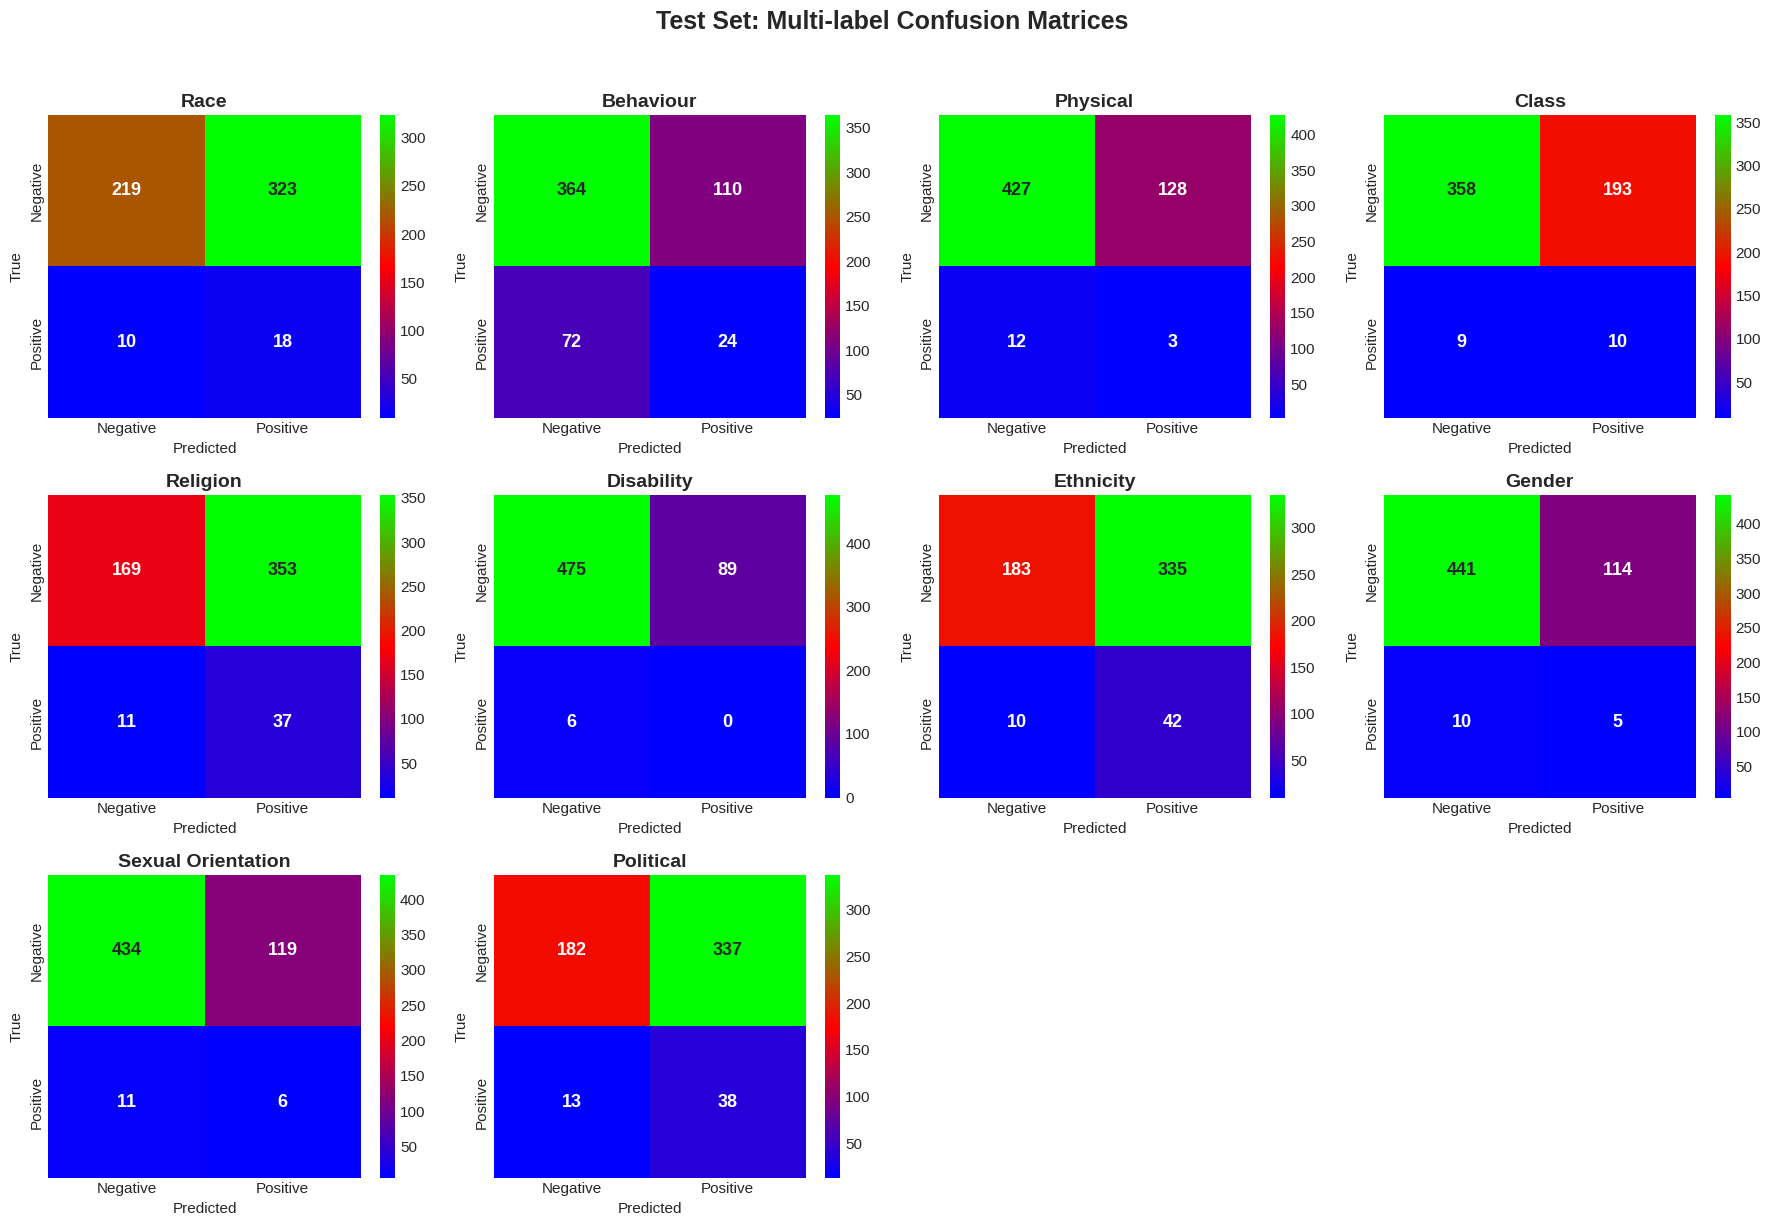

In [40]:
def plot_multilabel_confusion_matrices(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # 1. Gather predictions
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating Confusion Matrices"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()
            
            logits = model(input_ids)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # 2. Calculate the multi-label confusion matrix
    mcm = multilabel_confusion_matrix(all_labels, all_preds)
    num_classes = mcm.shape[0]

    # Use default names if none are provided
    if class_names is None or len(class_names) != num_classes:
        class_names = [f"Class {i}" for i in range(num_classes)]

    # 3. Dynamic plotting grid (adjusting for 10 classes -> 4 columns, 3 rows)
    cols = 4 
    rows = int(np.ceil(num_classes / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
    axes = axes.flatten()

    # 4. Plot each matrix
    for i, (matrix, ax, name) in enumerate(zip(mcm, axes, class_names)):
        sns.heatmap(matrix, annot=True, fmt="d", cmap="brg", cbar=True,
                    xticklabels=["Negative", "Positive"], 
                    yticklabels=["Negative", "Positive"], 
                    ax=ax,
                    annot_kws={"size": 13, "weight": "bold"})
        ax.set_title(f"{name}", fontweight='bold', fontsize=14)
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True", fontsize=11)

    # Remove any empty subplots if the grid isn't perfectly filled
    for j in range(num_classes, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Test Set: Multi-label Confusion Matrices", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()



# Execute strictly on the test set with your specific labels
plot_multilabel_confusion_matrices(model, test_loader, device, class_names=my_class_names)

In [41]:


def print_classification_report(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather predictions
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating Classification Report"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()
            
            logits = model(input_ids)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    print("\n" + "="*60)
    print("     DETAILED CLASSIFICATION REPORT (TEST SET)     ")
    print("="*60 + "\n")
    
    # Print the report using your specific target names
    report = classification_report(
        all_labels, 
        all_preds, 
        target_names=class_names, 
        zero_division=0
    )
    print(report)



# Execute strictly on the test set
print_classification_report(model, test_loader, device, class_names=my_class_names)

Generating Classification Report:   0%|          | 0/18 [00:00<?, ?it/s]


     DETAILED CLASSIFICATION REPORT (TEST SET)     

                    precision    recall  f1-score   support

              Race       0.05      0.64      0.10        28
         Behaviour       0.18      0.25      0.21        96
          Physical       0.02      0.20      0.04        15
             Class       0.05      0.53      0.09        19
          Religion       0.09      0.77      0.17        48
        Disability       0.00      0.00      0.00         6
         Ethnicity       0.11      0.81      0.20        52
            Gender       0.04      0.33      0.07        15
Sexual Orientation       0.05      0.35      0.08        17
         Political       0.10      0.75      0.18        51

         micro avg       0.08      0.53      0.14       347
         macro avg       0.07      0.46      0.11       347
      weighted avg       0.11      0.53      0.16       347
       samples avg       0.08      0.19      0.10       347



Generating ROC Curves:   0%|          | 0/18 [00:00<?, ?it/s]

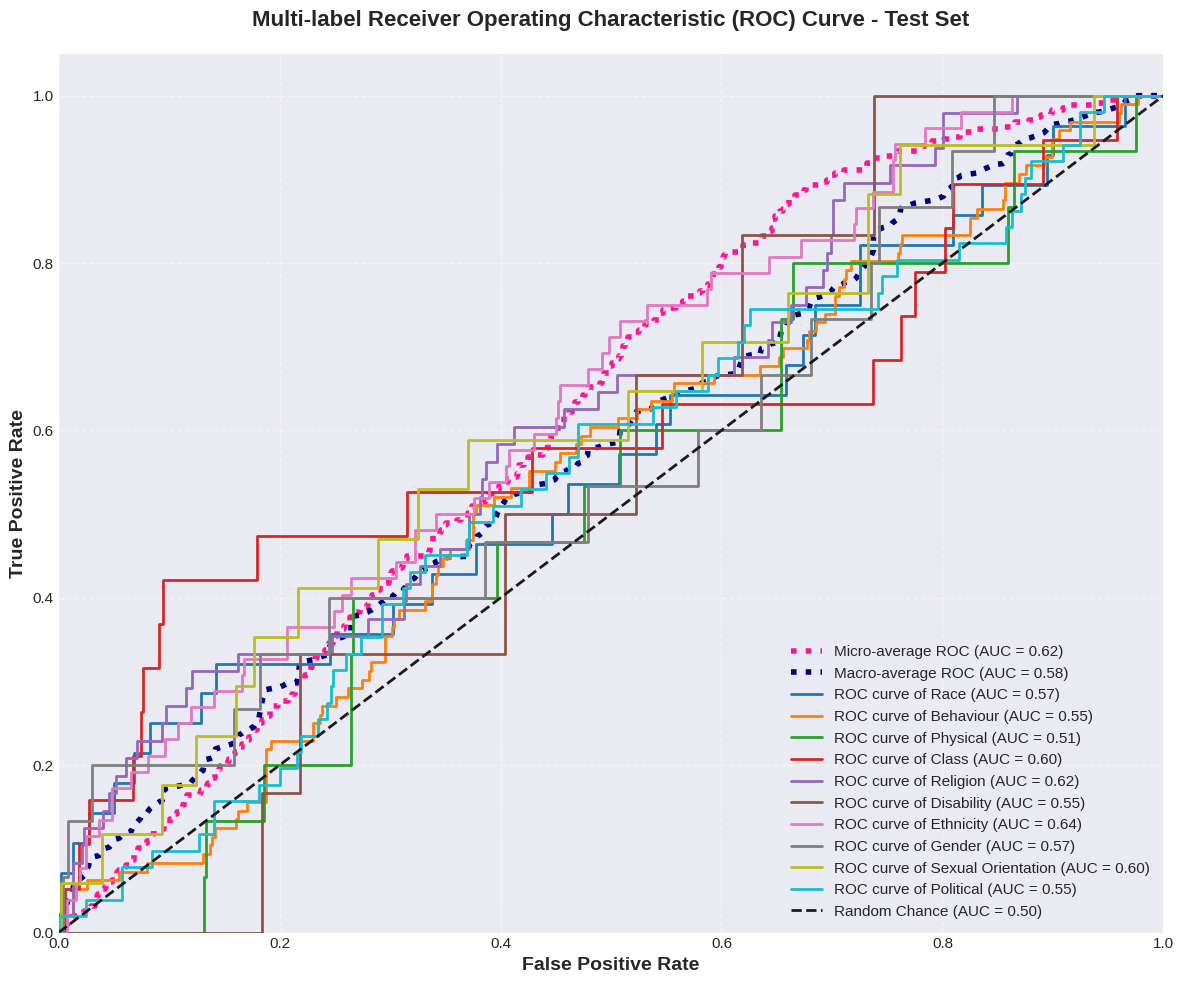

In [42]:
def plot_multilabel_roc_curve(model, dataloader, device, class_names):
    model.eval()
    all_probs = []
    all_labels = []

    # 1. Gather probabilities and true labels
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating ROC Curves"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()
            
            logits = model(input_ids)
            probs = torch.sigmoid(logits)  # We need probabilities for ROC, not binary preds
            
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    num_classes = len(class_names)

    # 2. Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        # Only calculate if there are both positive and negative samples
        if len(np.unique(all_labels[:, i])) > 1:
            fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        else:
            fpr[i], tpr[i], roc_auc[i] = np.array([0.0, 1.0]), np.array([0.0, 1.0]), 0.0

    # 3. Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # 4. Compute macro-average ROC curve and ROC area
    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
    
    # Then interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    
    # Finally average it and compute AUC
    mean_tpr /= num_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # 5. Plot all ROC curves
    plt.figure(figsize=(12, 10))
    
    # Plot Micro and Macro averages with distinct thick lines
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)
             
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)

    # Plot each individual class
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
                    
    for i, color in zip(range(num_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    # Plot random chance diagonal
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance (AUC = 0.50)')

    # Formatting the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title('Multi-label Receiver Operating Characteristic (ROC) Curve - Test Set', 
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc="lower right", fontsize=11, framealpha=0.9, edgecolor='black')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


# Execute strictly on the test set
plot_multilabel_roc_curve(model, test_loader, device, class_names=my_class_names)

Generating PR Curves:   0%|          | 0/18 [00:00<?, ?it/s]

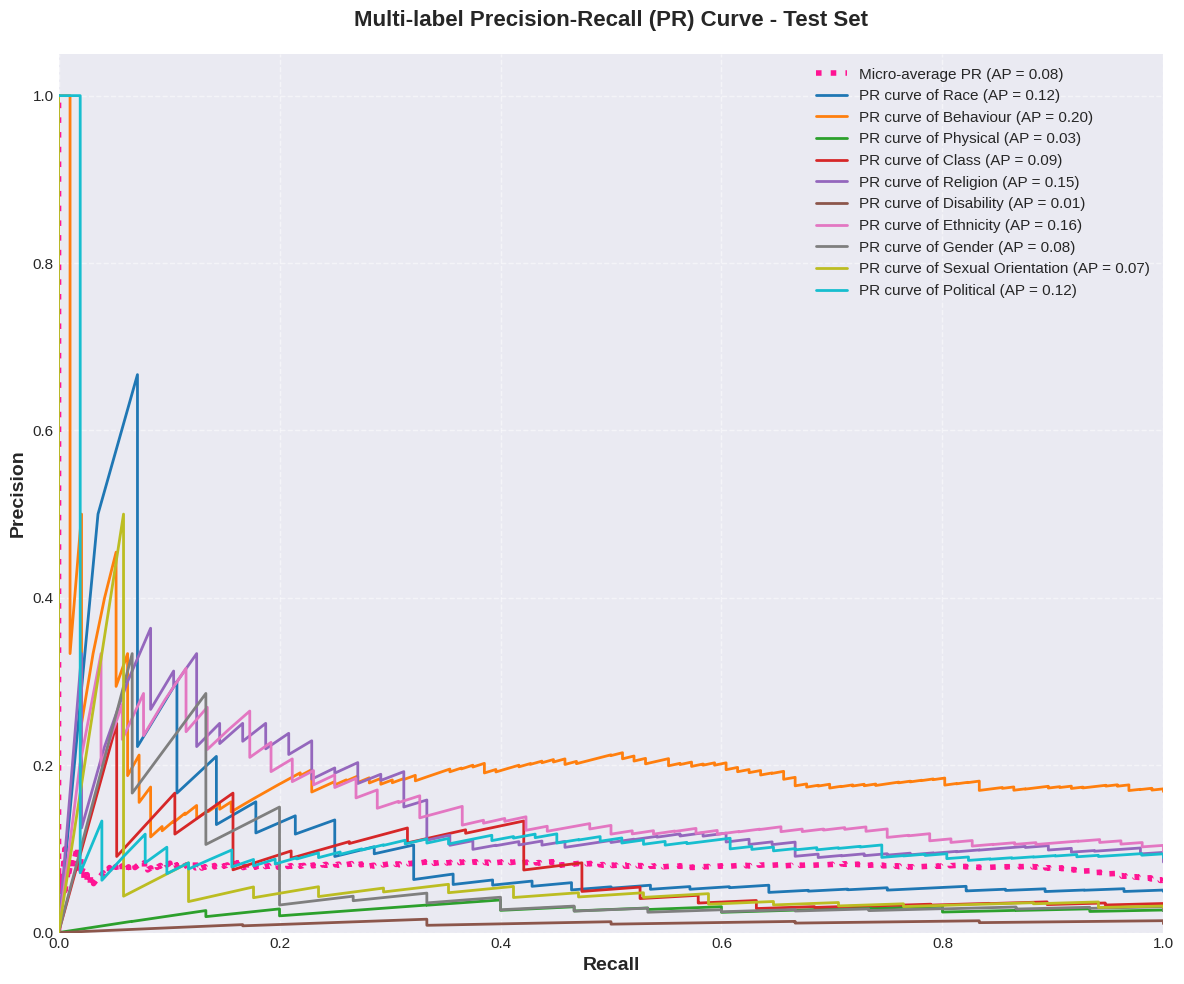

In [43]:

def plot_multilabel_pr_curve(model, dataloader, device, class_names):
    model.eval()
    all_probs = []
    all_labels = []

    # 1. Gather probabilities and true labels
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating PR Curves"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()
            
            logits = model(input_ids)
            probs = torch.sigmoid(logits)  # Probabilities needed for PR curve
            
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    num_classes = len(class_names)

    # 2. Compute Precision-Recall curve and AP for each class
    precision = dict()
    recall = dict()
    average_precision = dict()
    
    for i in range(num_classes):
        # Only calculate if there are both positive and negative samples
        if len(np.unique(all_labels[:, i])) > 1:
            precision[i], recall[i], _ = precision_recall_curve(all_labels[:, i], all_probs[:, i])
            average_precision[i] = average_precision_score(all_labels[:, i], all_probs[:, i])
        else:
            # Fallback if a batch/set is missing a class entirely
            precision[i], recall[i], average_precision[i] = np.array([0.0, 0.0]), np.array([0.0, 0.0]), 0.0

    # 3. Compute micro-average PR curve and AP
    precision["micro"], recall["micro"], _ = precision_recall_curve(all_labels.ravel(), all_probs.ravel())
    average_precision["micro"] = average_precision_score(all_labels, all_probs, average="micro")

    # 4. Plot all PR curves
    plt.figure(figsize=(12, 10))
    
    # Plot Micro-average
    plt.plot(recall["micro"], precision["micro"],
             label=f'Micro-average PR (AP = {average_precision["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    # Plot each individual class
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
                    
    for i, color in zip(range(num_classes), colors):
        plt.plot(recall[i], precision[i], color=color, lw=2,
                 label=f'PR curve of {class_names[i]} (AP = {average_precision[i]:.2f})')

    # Formatting the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=14, fontweight='bold')
    plt.ylabel('Precision', fontsize=14, fontweight='bold')
    plt.title('Multi-label Precision-Recall (PR) Curve - Test Set', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Place the legend in a clear spot
    plt.legend(loc="best", fontsize=11, framealpha=0.9, edgecolor='black')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Execute strictly on the test set using your dynamically extracted class names
plot_multilabel_pr_curve(model, test_loader, device, class_names=my_class_names)

Gathering Radar Data:   0%|          | 0/18 [00:00<?, ?it/s]

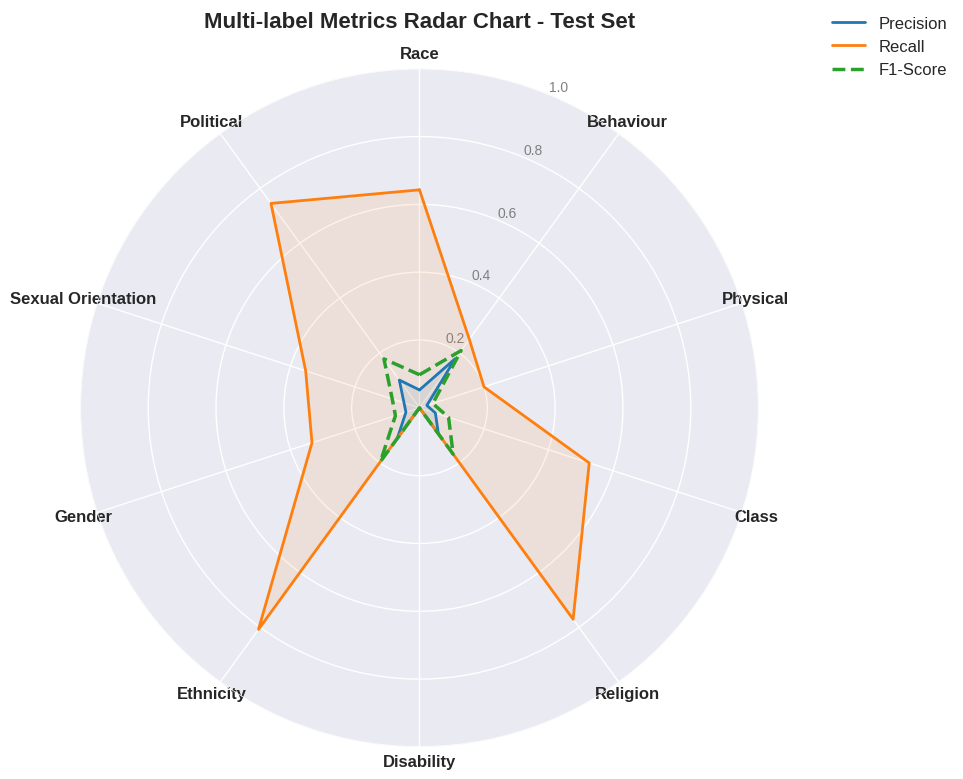

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import torch
from tqdm.auto import tqdm

def plot_multilabel_radar_chart(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    # 1. Gather predictions and true labels
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Gathering Radar Data"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()
            
            logits = model(input_ids)
            probs = torch.sigmoid(logits)
            
            # Using the standard 0.5 threshold
            preds = (probs >= 0.5).float()
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # 2. Extract metrics per class using classification_report
    report = classification_report(
        all_labels, 
        all_preds, 
        target_names=class_names, 
        zero_division=0, 
        output_dict=True
    )
    
    precisions = [report[cls]['precision'] for cls in class_names]
    recalls = [report[cls]['recall'] for cls in class_names]
    f1_scores = [report[cls]['f1-score'] for cls in class_names]

    # 3. Setup Radar Chart Angles
    num_vars = len(class_names)
    # Calculate the angle for each category
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # Close the loop so the chart connects the last point back to the first
    angles += angles[:1]
    precisions += precisions[:1]
    recalls += recalls[:1]
    f1_scores += f1_scores[:1]
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Rotate the chart so the first category is at the very top
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw one axe per variable + add labels
    ax.set_thetagrids(np.degrees(angles[:-1]), class_names, fontsize=12, fontweight='bold')
    
    # Set y-axis bounds and grid lines
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color="grey", size=10)
    
    # Plot Precision (Blue)
    ax.plot(angles, precisions, color='#1f77b4', linewidth=2, label='Precision')
    ax.fill(angles, precisions, color='#1f77b4', alpha=0.1)
    
    # Plot Recall (Orange)
    ax.plot(angles, recalls, color='#ff7f0e', linewidth=2, label='Recall')
    ax.fill(angles, recalls, color='#ff7f0e', alpha=0.1)
    
    # Plot F1-Score (Green, dashed)
    ax.plot(angles, f1_scores, color='#2ca02c', linewidth=2.5, linestyle='dashed', label='F1-Score')
    
    # Formatting
    plt.title('Multi-label Metrics Radar Chart - Test Set', size=16, fontweight='bold', pad=30)
    
    # Move legend out of the way
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12, edgecolor='black', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# Execute strictly on the test set
plot_multilabel_radar_chart(model, test_loader, device, my_class_names)

Extracting Model Logits:   0%|          | 0/18 [00:00<?, ?it/s]

Running t-SNE reduction... (This may take a minute or two)


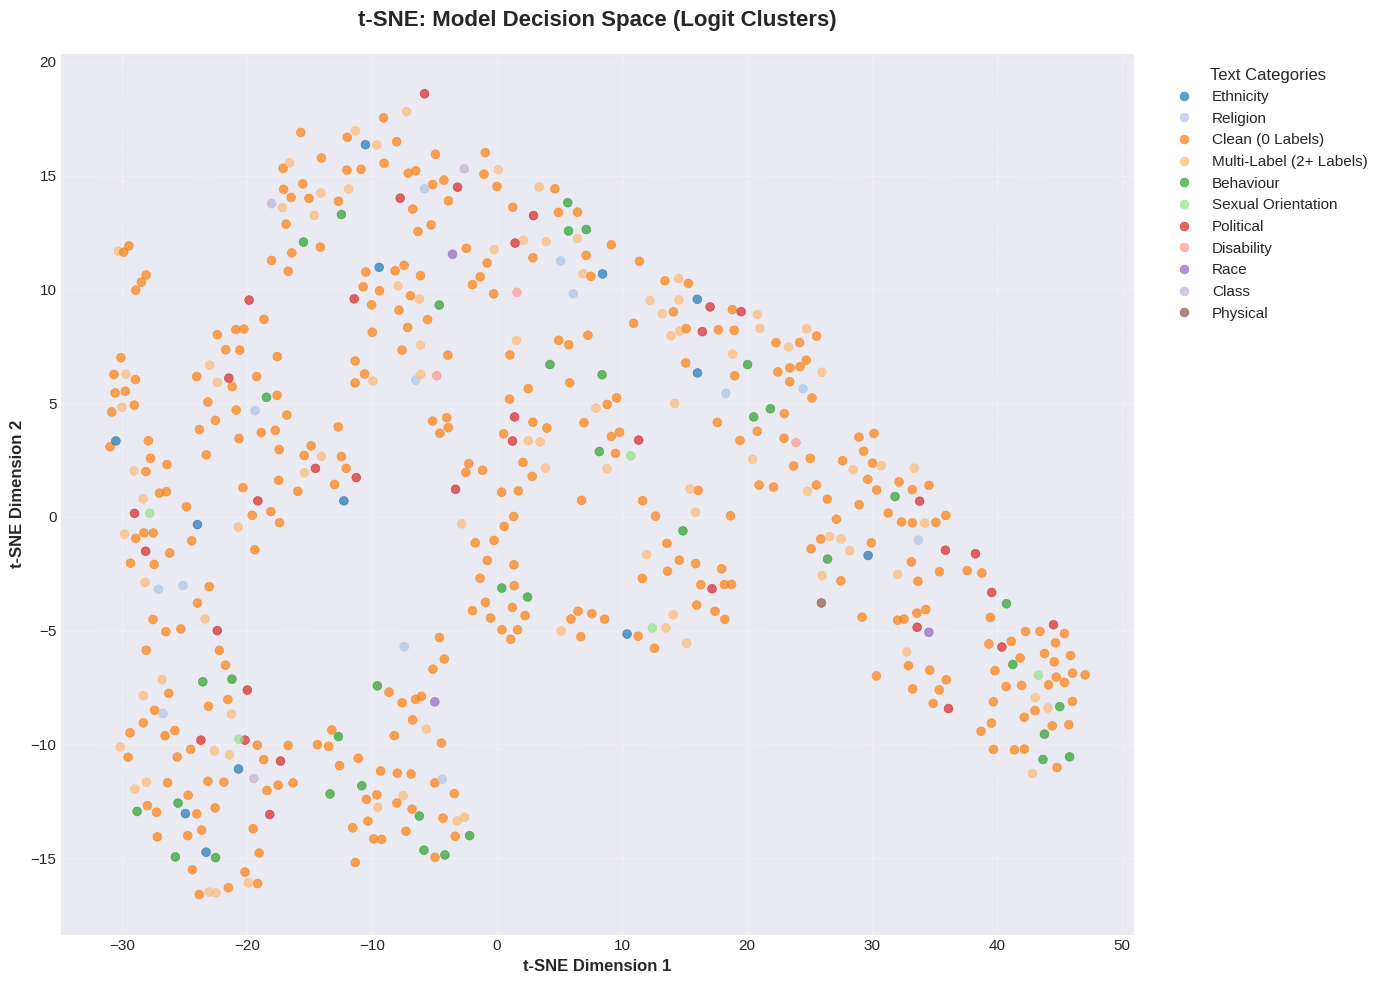

In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

def plot_multilabel_tsne(model, dataloader, device, class_names):
    model.eval()
    all_logits = []
    all_labels = []

    # 1. Extract raw logits (internal model features) and labels
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting Model Logits"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device).float()
            
            # Forward pass: getting raw logits instead of probs for better t-SNE
            logits = model(input_ids)
            
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_logits = np.vstack(all_logits)
    all_labels = np.vstack(all_labels)

    # 2. Assign a single color category to each multi-label row
    color_categories = []
    for row in all_labels:
        label_count = np.sum(row)
        if label_count == 0:
            color_categories.append("Clean (0 Labels)")
        elif label_count > 1:
            color_categories.append("Multi-Label (2+ Labels)")
        else:
            # If exactly 1 label, find out which one it is
            idx = np.argmax(row)
            color_categories.append(class_names[idx])

    # 3. Run t-SNE mathematically 
    # (Reduces the 10-dimensional logit space down to 2 dimensions)
    print("Running t-SNE reduction... (This may take a minute or two)")
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(all_logits)

    # 4. Plot the results using Seaborn
    plt.figure(figsize=(14, 10))
    
    # We use a color palette that supports many distinct categories
    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1],
        hue=color_categories,
        palette="tab20", 
        alpha=0.7,
        s=40,
        edgecolor=None
    )
    
    # 5. Formatting
    plt.title('t-SNE: Model Decision Space (Logit Clusters)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
    plt.ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
    
    # Move the legend outside the plot so it doesn't cover the data points
    plt.legend(title="Text Categories", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute strictly on the test set
plot_multilabel_tsne(model, test_loader, device, my_class_names)

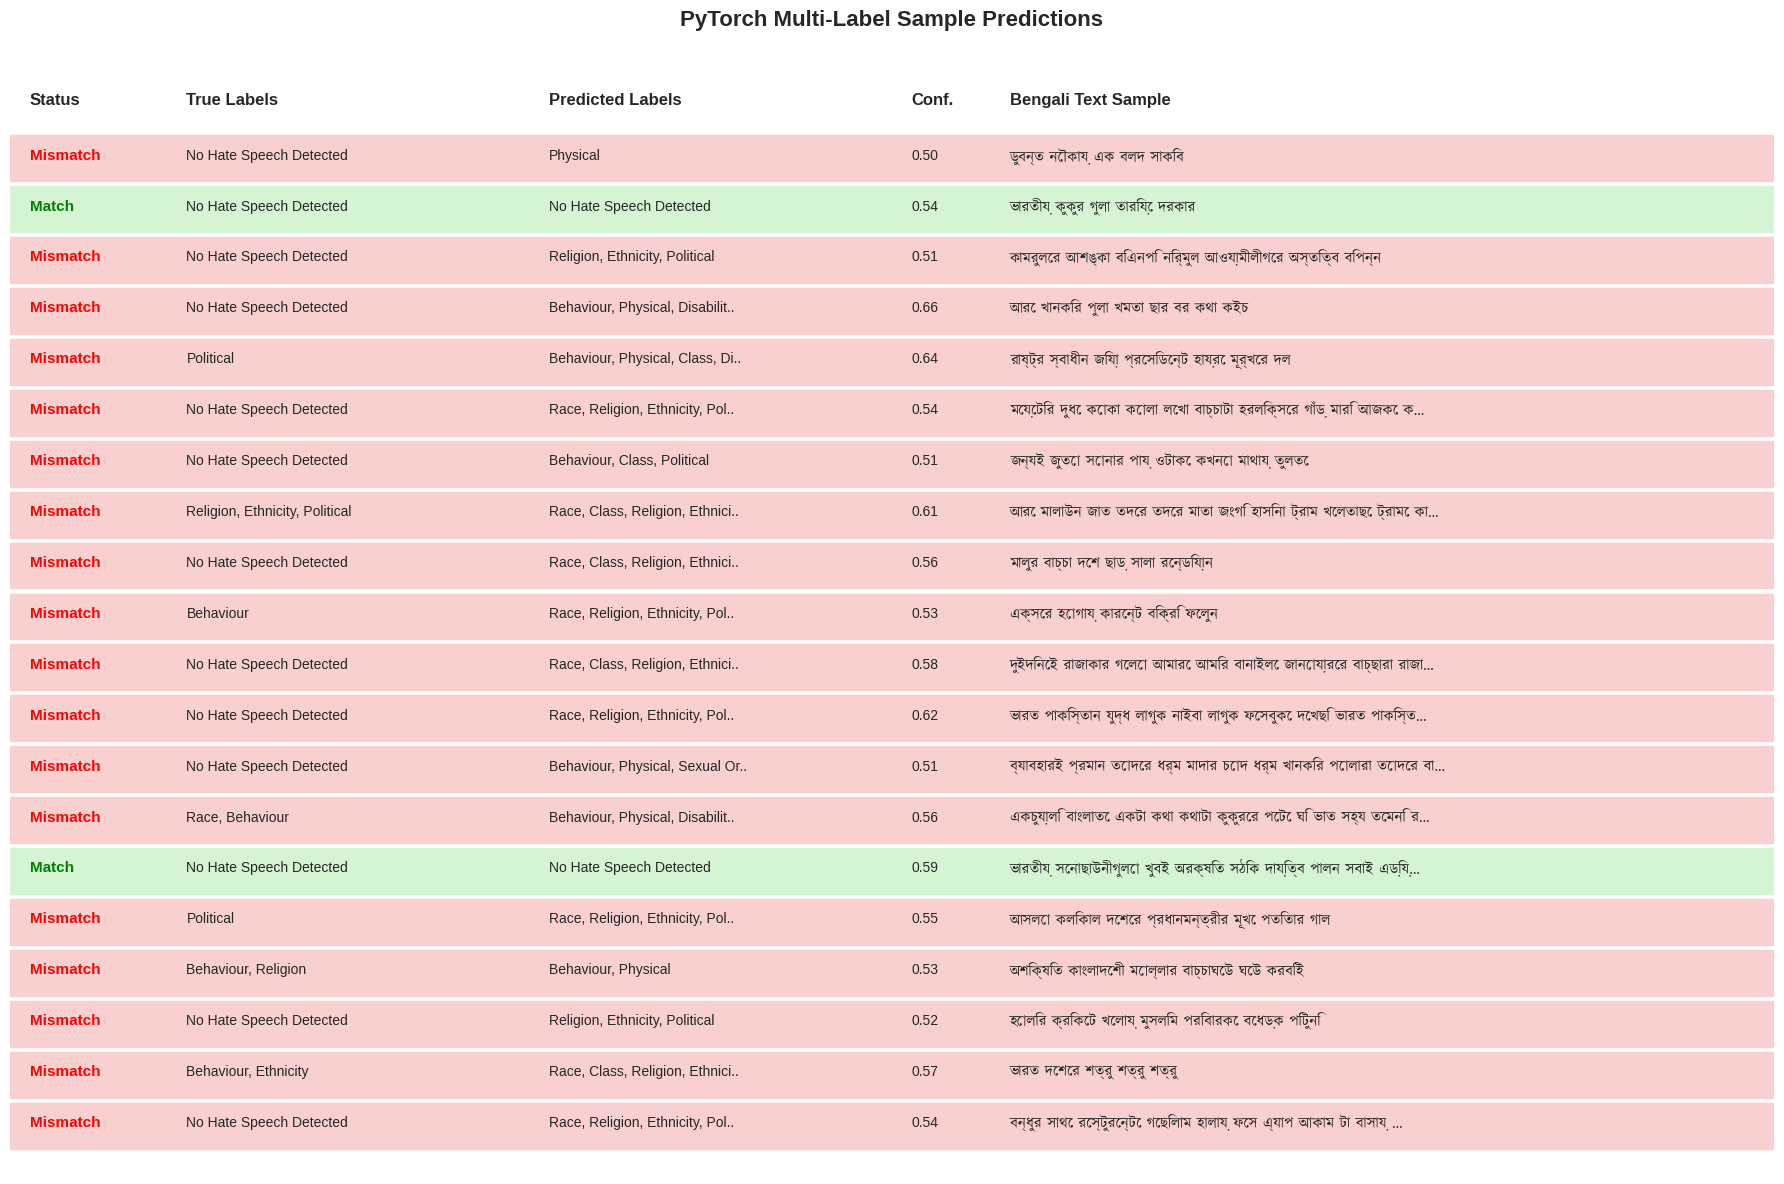

In [46]:

def plot_multilabel_predictions_image(model, dataset, device, class_names, bangla_font_path, num_samples=20):
    # 1. Setup Bengali Font
    bangla_font = font_manager.FontProperties(fname=bangla_font_path)
    
    # 2. Set Model to Evaluation Mode
    model.eval()
    
    # 3. Randomly sample from your test dataset
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    results = []
    with torch.no_grad():
        for idx in indices:
            sample = dataset[idx]
            text = sample['text'] 
            
            # Add batch dimension and send to GPU/CPU
            input_ids = sample['input_ids'].unsqueeze(0).to(device)
            true_labels = sample['labels'].numpy()
            
            # Forward pass
            logits = model(input_ids)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            
            # ==========================================================
            # EXTRACT ONLY THE ORIGINAL STRING LABELS
            # ==========================================================
            true_names = [class_names[i] for i, val in enumerate(true_labels) if val == 1.0]
            pred_names = [class_names[i] for i, val in enumerate(preds) if val == 1.0]
            
            # Explicitly state what '0' means for anyone reading the chart
            true_str = ", ".join(true_names) if true_names else "No Hate Speech Detected"
            pred_str = ", ".join(pred_names) if pred_names else "No Hate Speech Detected"
            
            # Determine Correctness (Exact Match)
            is_correct = np.array_equal(true_labels, preds)
            
            # Calculate Confidence
            if sum(preds) > 0:
                conf = np.mean([probs[i] for i, val in enumerate(preds) if val == 1.0])
            else:
                conf = np.mean([1 - probs[i] for i, val in enumerate(preds) if val == 0.0])
                
            results.append({
                "Text": text,
                "True": true_str,
                "Pred": pred_str,
                "Confidence": conf,
                "Correct": is_correct
            })
            
    df_check = pd.DataFrame(results)
    
    # ==========================================
    # PLOTTING
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, num_samples * 0.6))
    ax.axis("off")
    
    for i, row in df_check.iterrows():
        y_pos = len(df_check) - i
        
        # Colors & Status
        color = "#d4f4d4" if row["Correct"] else "#f9d0d0"
        status = "Match" if row["Correct"] else "Mismatch"
        status_color = "green" if row["Correct"] else "red"
        
        # Text Truncation
        text_short = str(row["Text"])[:65] + "..." if len(str(row["Text"])) > 65 else str(row["Text"])
        true_short = row["True"][:30] + ".." if len(row["True"]) > 30 else row["True"]
        pred_short = row["Pred"][:30] + ".." if len(row["Pred"]) > 30 else row["Pred"]
        
        # Draw background rectangle
        ax.add_patch(
            plt.Rectangle((0, y_pos - 0.5), 18, 0.9, color=color, zorder=0)
        )
        
        # Draw text inside columns
        ax.text(0.2, y_pos, status, fontsize=11, va="center", color=status_color, fontweight="bold")
        ax.text(1.8, y_pos, true_short, fontsize=10, va="center")
        ax.text(5.5, y_pos, pred_short, fontsize=10, va="center")
        ax.text(9.2, y_pos, f"{row['Confidence']:.2f}", fontsize=10, va="center")
        ax.text(10.2, y_pos, text_short, fontsize=11, va="center", fontproperties=bangla_font)

    # Add Column Headers
    header_y = len(df_check) + 1
    ax.text(0.2, header_y, "Status", fontsize=12, fontweight="bold")
    ax.text(1.8, header_y, "True Labels", fontsize=12, fontweight="bold")
    ax.text(5.5, header_y, "Predicted Labels", fontsize=12, fontweight="bold")
    ax.text(9.2, header_y, "Conf.", fontsize=12, fontweight="bold")
    ax.text(10.2, header_y, "Bengali Text Sample", fontsize=12, fontweight="bold")

    ax.set_xlim(0, 18)
    ax.set_ylim(0, len(df_check) + 2)
    plt.title("PyTorch Multi-Label Sample Predictions", fontsize=16, pad=20, fontweight="bold")
    plt.tight_layout()
    plt.savefig("multilabel_sample_predictions.png", dpi=300, bbox_inches="tight")
    plt.show()

# ==========================================
# EXECUTE THE FUNCTION
# ==========================================
FONT_PATH = "/kaggle/input/datasets/programminghero009/bangla-font/kalpurush.ttf"

plot_multilabel_predictions_image(
    model=model, 
    dataset=test_dataset,  
    device=device, 
    class_names=my_class_names, 
    bangla_font_path=FONT_PATH,
    num_samples=20         
)